# Other machine learning approaches for classification: Random Forest

In [6]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

random_seed = 10
random.seed(random_seed)
np.random.seed(random_seed)

## Data preparation
### Load data

In [7]:
data = pd.read_csv(os.path.join(".", "data", "features_30_sec.csv"))

X = data.iloc[:, 2:-1].values  # All feature columns
y = data.iloc[:, -1].values     # Label column

print(f"Dataset loaded:\n")
print(f"Total samples:     {len(X)}")
print(f"Features:          {X.shape[1]}")
print(f"Classes:           {sorted(set(y))}")
print(f"Samples per class: {pd.Series(y).value_counts().to_dict()}")


Dataset loaded:

Total samples:     1000
Features:          57
Classes:           ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Samples per class: {'blues': 100, 'classical': 100, 'country': 100, 'disco': 100, 'hiphop': 100, 'jazz': 100, 'metal': 100, 'pop': 100, 'reggae': 100, 'rock': 100}


### Split into training and test datasets

In [8]:
# Stratified train/test split to ensure balanced class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=random_seed, 
    stratify=y
)

print(f"Dataset split (stratified):\n")
print(f"Training:   {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test:       {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Training class distribution: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test class distribution:     {pd.Series(y_test).value_counts().to_dict()}")

Dataset split (stratified):

Training:   800 samples (80.0%)
Test:       200 samples (20.0%)
Training class distribution: {'reggae': 80, 'jazz': 80, 'country': 80, 'disco': 80, 'pop': 80, 'hiphop': 80, 'blues': 80, 'metal': 80, 'classical': 80, 'rock': 80}
Test class distribution:     {'blues': 20, 'metal': 20, 'country': 20, 'rock': 20, 'classical': 20, 'disco': 20, 'pop': 20, 'hiphop': 20, 'reggae': 20, 'jazz': 20}


## Define pipelines

In [9]:
RF_pipeline = RFC(n_estimators=200, max_depth=10, max_features='sqrt', random_state=random_seed)

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
cv_results = {}

# Perform 5-fold cross-validation
scores = cross_val_score(
    RF_pipeline, X_train, y_train, 
    cv=cv, 
    scoring='accuracy',
    n_jobs=-1
)

cv_results["RFC"] = {
    'cv_mean': scores.mean(),
    'cv_std': scores.std(),
    'cv_scores': scores
}

print(f"Cross-validation accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Fold scores:               {[f'{s:.3f}' for s in scores]}")

Cross-validation accuracy: 0.703 ± 0.025
Fold scores:               ['0.694', '0.744', '0.669', '0.694', '0.713']


## Tuning hyperparameters
### Pipeline for tuning

In [11]:
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [20, 30, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print(f"\nSearching {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']) * len(param_grid['max_features'])} combinations...")

# Grid search with cross-validation
grid_search = GridSearchCV(
    RF_pipeline,
    param_grid,
    cv=cv,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)
print(f"Best cross-validation score: {grid_search.best_score_:.3f}")



Searching 288 combinations...
Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best cross-validation score: 0.714


Best parameters found in grid search:

In [12]:
grid_search.best_params_

{'max_depth': 20,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 500}

In [13]:
# Get the best model
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Set Accuracy:            {test_accuracy:.3f}")
print(f"CV accuracy (for comparison): {grid_search.best_score_:.3f}")
print(f"Difference:                   {abs(test_accuracy - grid_search.best_score_):.3f}\n")

if abs(test_accuracy - grid_search.best_score_) < 0.05:
    print("CV and test scores are close (< 5% difference)")
else:
    print("Warning: > 5\% difference between CV and test scores")

# Classification report
print("\n" + "="*55)
print("Classification report:")
print("="*55)
print(classification_report(y_test, y_pred))

Test Set Accuracy:            0.710
CV accuracy (for comparison): 0.714
Difference:                   0.004

CV and test scores are close (< 5% difference)

Classification report:
              precision    recall  f1-score   support

       blues       0.81      0.65      0.72        20
   classical       0.81      0.85      0.83        20
     country       0.67      0.60      0.63        20
       disco       0.75      0.75      0.75        20
      hiphop       0.76      0.65      0.70        20
        jazz       0.75      0.75      0.75        20
       metal       0.79      0.95      0.86        20
         pop       0.83      0.75      0.79        20
      reggae       0.59      0.50      0.54        20
        rock       0.45      0.65      0.53        20

    accuracy                           0.71       200
   macro avg       0.72      0.71      0.71       200
weighted avg       0.72      0.71      0.71       200



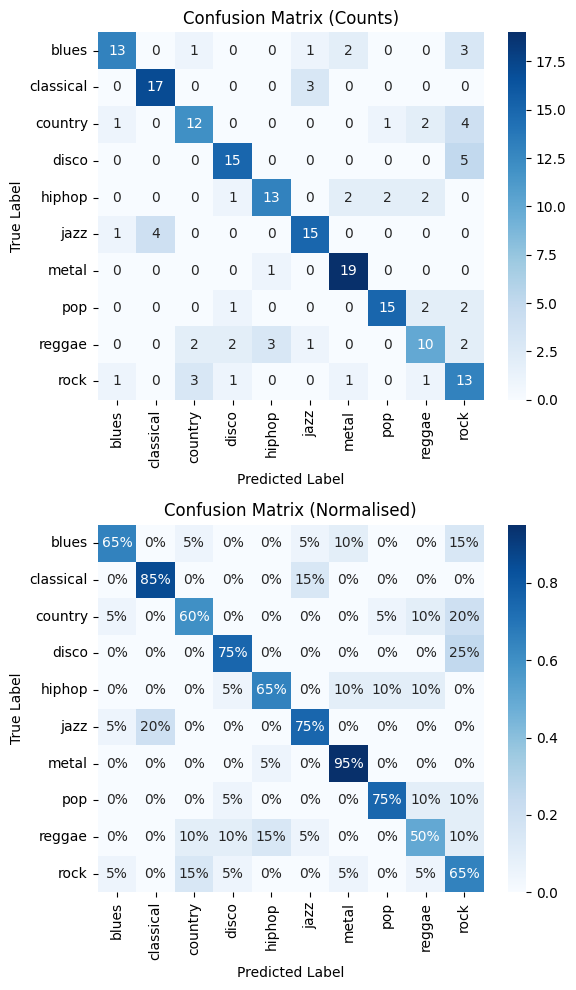

In [14]:
classes = sorted(set(y))

# Assemble confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=classes)
cm_normalised = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,10))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=classes, yticklabels=classes)
ax1.set_title('Confusion Matrix (Counts)')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# Normalised (percentages)
sns.heatmap(cm_normalised, annot=True, fmt='.0%', cmap='Blues', ax=ax2,
            xticklabels=classes, yticklabels=classes)
ax2.set_title('Confusion Matrix (Normalised)')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()
